<a href="https://colab.research.google.com/github/hemajuluri/Ethical-and-fairness/blob/main/01_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Configuration and Setup

In [2]:
import os
from google.colab import drive

# Mount Google Drive (will only prompt once per session if not already mounted)
drive.mount('/content/drive', force_remount=True)

# Define base directories
base_dir = '/content/drive/MyDrive/Thesis/src/'
data_raw_dir = os.path.join(base_dir, 'data_raw')
artifacts_dir = os.path.join(base_dir, 'artifacts')

# Ensure artifacts directory exists
os.makedirs(artifacts_dir, exist_ok=True)

# Define specific file paths
raw_data_file = os.path.join(data_raw_dir, 'application_train.csv')
experiment_log_file = os.path.join(artifacts_dir, 'experiment_log.csv')

print(f"Base Directory: {base_dir}")
print(f"Raw Data Directory: {data_raw_dir}")
print(f"Artifacts Directory: {artifacts_dir}")
print(f"Raw Data File: {raw_data_file}")
print(f"Experiment Log File: {experiment_log_file}")

Mounted at /content/drive
Base Directory: /content/drive/MyDrive/Thesis/src/
Raw Data Directory: /content/drive/MyDrive/Thesis/src/data_raw
Artifacts Directory: /content/drive/MyDrive/Thesis/src/artifacts
Raw Data File: /content/drive/MyDrive/Thesis/src/data_raw/application_train.csv
Experiment Log File: /content/drive/MyDrive/Thesis/src/artifacts/experiment_log.csv


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the raw data
df = pd.read_csv(raw_data_file)

# 2. Take a 10% Stratified Sample for speed
def stratified_sample(df, stratify_col, frac, random_state=None):
    sampled_dfs = []
    for group_name, group_df in df.groupby(stratify_col):
        sampled_dfs.append(group_df.sample(frac=frac, random_state=random_state))
    return pd.concat(sampled_dfs)

df_sample = stratified_sample(df, 'TARGET', frac=0.1, random_state=42)

# 3. Define X and y
X = df_sample.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_sample['TARGET']

# 4. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Sample size: {len(df_sample)} | Training size: {len(X_train)} | Test size: {len(X_test)}")

Sample size: 30751 | Training size: 24600 | Test size: 6151


In [4]:
# Fix DAYS_EMPLOYED anomaly
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, df['DAYS_EMPLOYED'].median())

# Engineered features
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['EMPLOYMENT_PERCENT']   = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
df['GOODS_PRICE_RATIO']    = df['AMT_CREDIT']  / df['AMT_GOODS_PRICE']
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

In [5]:
# Exclude gender from model features
X = df_sample.drop(['TARGET', 'SK_ID_CURR', 'CODE_GENDER'], axis=1)

After running the above cell, carefully inspect the output to find the exact path to your `application_train.csv` file. Once you have the correct path, update the `raw_data_path` variable in the first code cell (`zenevoh1JZbF`) to reflect the correct location. For example, if your file is directly under `MyDrive`, you would change it to `'/content/drive/MyDrive/application_train.csv'`.

In [6]:
import joblib
import pandas as pd # pandas is also needed for pd.read_csv

# 2. Re-hydrate the "Baton"
model_smote = joblib.load(os.path.join(artifacts_dir, 'logistic_reg_smote_model.pkl'))
preprocessor = joblib.load(os.path.join(artifacts_dir, 'preprocessor_pipeline.pkl'))
X_test = pd.read_csv(os.path.join(artifacts_dir, 'X_test_final.csv'))
y_test = pd.read_csv(os.path.join(artifacts_dir, 'y_test_final.csv'))

# 3. Re-process the test data (required for analysis)
X_test_proc = preprocessor.transform(X_test)

print("✅ State restored. You can now run any analysis cell below.")

✅ State restored. You can now run any analysis cell below.


In [7]:
# Run this to verify the balance is preserved
print("Target distribution in Sample:")
print(df_sample['TARGET'].value_counts(normalize=True))

Target distribution in Sample:
TARGET
0    0.919287
1    0.080713
Name: proportion, dtype: float64


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit and transform
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [9]:
# 1. Check the type (Should be a numpy array or matrix)
print(f"Data Type: {type(X_train_proc)}")

# 2. Check the shape (The number of columns should have grown)
print(f"Original columns: {X_train.shape[1]}")
print(f"Processed columns: {X_train_proc.shape[1]}")

# 3. Peek at the first row of numbers
print("\nFirst row of processed data:")
print(X_train_proc[0])

Data Type: <class 'numpy.ndarray'>
Original columns: 120
Processed columns: 239

First row of processed data:
[-5.72705512e-01  1.55189132e+00  1.86315415e-01 -5.26717661e-01
  3.68095271e-01  7.19275859e-01 -9.87722140e-01  2.13091137e+00
  3.92939473e-01 -4.23687714e-01 -1.46166966e-01  0.00000000e+00
 -2.13114727e+00 -5.02539376e-01  4.23299276e-02 -6.23986810e-01
 -2.45558802e-01 -1.25608400e+00 -1.10544523e-01 -6.53969309e-02
  2.86506174e-01  7.78807649e+00 -2.33122205e-01 -2.06061218e-01
  3.40908453e+00 -5.49859328e-01 -4.68650316e-01  1.50975183e+00
  2.20082800e-01 -5.28083423e-01 -9.32620922e-01 -9.51047478e-02
  1.91513591e-01  1.14728671e+00 -1.61621482e-01 -3.67134018e-01
 -1.06722108e+00 -2.81042832e-01 -7.30110729e-02 -7.19210127e-01
 -1.42850918e-01 -8.99153992e-01 -1.04163189e-01 -2.26216643e-01
 -8.78888099e-01 -9.41364789e-02  1.82081423e-01  1.21778564e+00
 -1.63407287e-01 -3.55479207e-01 -1.02756853e+00 -2.65002831e-01
 -6.00070272e-02 -6.72136048e-01 -1.59277626e

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score
import datetime

# 1. Train Baseline (No SMOTE yet)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_proc, y_train)

# 2. Evaluate
y_pred = model.predict(X_test_proc)
y_prob = model.predict_proba(X_test_proc)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# 3. Append to the Log File
new_entry = pd.DataFrame([{
    "Exp_ID": "EXP_01",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "Baseline",
    "Value": "No SMOTE / 10% Sample",
    "ROC_AUC": round(auc, 4),
    "F1_Score": round(f1, 4),
    "Recall": round(recall, 4),
    "Notes": "Baseline model. High accuracy but low recall expected due to imbalance."
}])

new_entry.to_csv(experiment_log_file, mode='a', header=False, index=False)
print(f"✅ EXP_01 Logged! AUC: {auc:.4f}")

✅ EXP_01 Logged! AUC: 0.7295


In [11]:
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE only to the processed training data
smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

# 2. Train the same model on the BALANCED data
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_res, y_train_res)

# 3. Evaluate on the untouched processed test set
y_pred_smote = model_smote.predict(X_test_proc)
y_prob_smote = model_smote.predict_proba(X_test_proc)[:, 1]

auc_smote = roc_auc_score(y_test, y_prob_smote)
f1_smote = f1_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)

# 4. Log the "Baton" for Experiment 02
new_entry_smote = pd.DataFrame([{
    "Exp_ID": "EXP_02",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "SMOTE Balancing",
    "Value": "Balanced (50/50 ratio)",
    "ROC_AUC": round(auc_smote, 4),
    "F1_Score": round(f1_smote, 4),
    "Recall": round(recall_smote, 4),
    "Notes": "Applied SMOTE to training set. Expecting a significant jump in Recall."
}])

new_entry_smote.to_csv(experiment_log_file, mode='a', header=False, index=False)
print(f"✅ EXP_02 Logged! AUC: {auc_smote:.4f} | Recall: {recall_smote:.4f}")

✅ EXP_02 Logged! AUC: 0.7261 | Recall: 0.1895


In [12]:
## EXP_03: Threshold Tuning on SMOTE Model
#Using the Precision-Recall curve to find the optimal decision threshold that maximises F1-score, directly addressing the recall deficit in EXP_02 while keeping Logistic Regression as the sole classifier.


✅ Best threshold found: 0.3270
   At this threshold → Precision: 0.2105 | Recall: 0.4113 | F1: 0.2785

EXP_03 Results:
  ROC-AUC : 0.7261
  F1 Score: 0.2785
  Recall  : 0.4113

✅ EXP_03 logged to experiment_log.csv


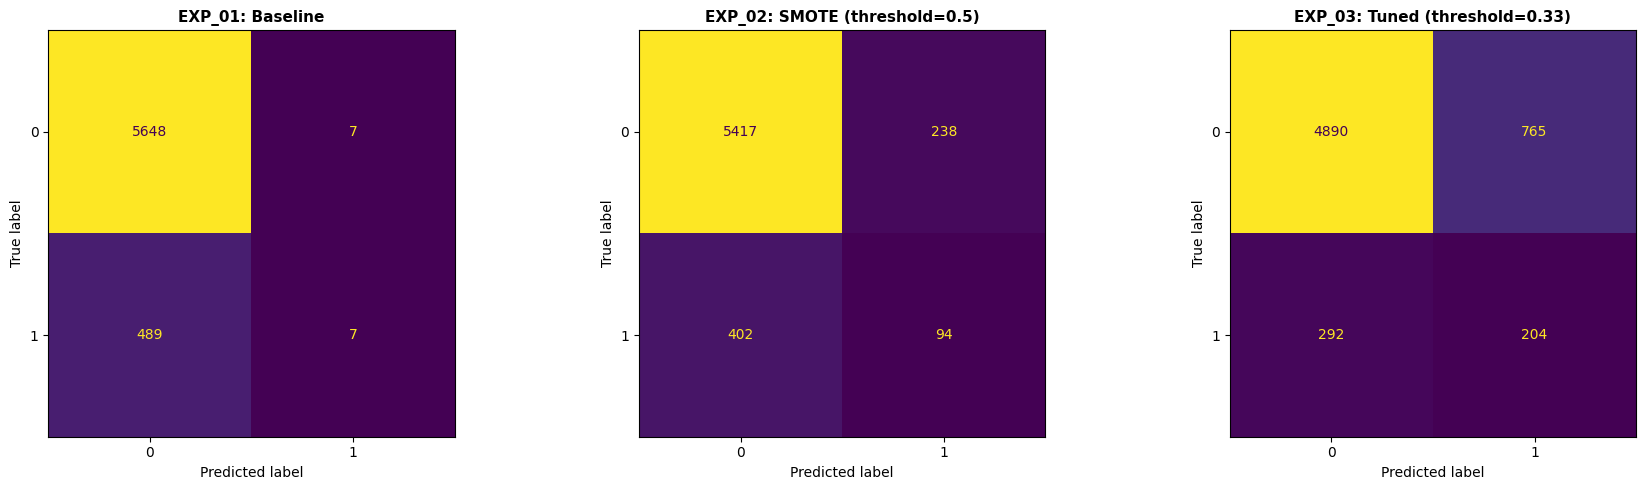

✅ Confusion matrix saved.


,Exp_ID,Description,ROC_AUC,F1,Recall
0,EXP_01,"Baseline (no SMOTE, threshold=0.5)",0.7295,0.0275,0.0141
1,EXP_02,SMOTE (threshold=0.5),0.7261,0.2271,0.1895
2,EXP_03,SMOTE + Threshold=0.33,0.7261,0.2785,0.4113


In [13]:
import numpy as np
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (
    precision_recall_curve, roc_auc_score,
    f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)

# ── Step 1: Get predicted probabilities from the SMOTE model ──────────────────
y_prob_smote = model_smote.predict_proba(X_test_proc)[:, 1]

# ── Step 2: Compute Precision-Recall curve & find best threshold ──────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_smote)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"✅ Best threshold found: {best_threshold:.4f}")
print(f"   At this threshold → Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

# ── Step 3: Apply the tuned threshold ─────────────────────────────────────────
y_pred_tuned = (y_prob_smote >= best_threshold).astype(int)

auc_exp3  = roc_auc_score(y_test, y_prob_smote)
f1_exp3   = f1_score(y_test, y_pred_tuned)
recall_exp3 = recall_score(y_test, y_pred_tuned)

print(f"\nEXP_03 Results:")
print(f"  ROC-AUC : {auc_exp3:.4f}")
print(f"  F1 Score: {f1_exp3:.4f}")
print(f"  Recall  : {recall_exp3:.4f}")

# ── Step 4: Log to experiment CSV ─────────────────────────────────────────────

new_entry_exp3 = pd.DataFrame([{
    "Exp_ID": "EXP_03",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "Threshold Tuning",
    "Value": f"Threshold={best_threshold:.4f} (PR-curve F1-optimal)",
    "ROC_AUC": round(auc_exp3, 4),
    "F1_Score": round(f1_exp3, 4),
    "Recall": round(recall_exp3, 4),
    "Notes": "Threshold optimised via Precision-Recall curve on SMOTE model. No new training."
}])
new_entry_exp3.to_csv(experiment_log_file, mode='a', header=False, index=False)
print(f"\n✅ EXP_03 logged to experiment_log.csv")

# ── Step 5: Confusion Matrix ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_base  = confusion_matrix(y_test, model.predict(X_test_proc))
cm_smote = confusion_matrix(y_test, model_smote.predict(X_test_proc))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

for ax, cm, title in zip(axes,
                          [cm_base, cm_smote, cm_tuned],
                          ["EXP_01: Baseline", "EXP_02: SMOTE (threshold=0.5)", f"EXP_03: Tuned (threshold={best_threshold:.2f})"]):
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'confusion_matrix_EXP01_EXP02_EXP03.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved.")

# ── Step 6: Summary table ─────────────────────────────────────────────────────
summary = pd.DataFrame([
    {"Exp_ID": "EXP_01", "Description": "Baseline (no SMOTE, threshold=0.5)", "ROC_AUC": 0.7295, "F1": 0.0275, "Recall": 0.0141},
    {"Exp_ID": "EXP_02", "Description": "SMOTE (threshold=0.5)",               "ROC_AUC": 0.7261, "F1": 0.2271, "Recall": 0.1895},
    {"Exp_ID": "EXP_03", "Description": f"SMOTE + Threshold={best_threshold:.2f}", "ROC_AUC": round(auc_exp3,4), "F1": round(f1_exp3,4), "Recall": round(recall_exp3,4)}
])
display(summary)

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE, ADASYN

# Initialize a clean dictionary to log comparative experimental states
results_log = {}

def log_experiment(exp_name, y_true, y_pred, y_proba):
    results_log[exp_name] = {
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1-Score": round(f1_score(y_true, y_pred), 4)
    }

# --- EXPERIMENT 1: Unbalanced Baseline (What you had originally) ---
lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_proc, y_train)
raw_preds = lr_raw.predict(X_test_proc)
raw_probs = lr_raw.predict_proba(X_test_proc)[:, 1]
log_experiment("Raw Unbalanced Baseline", y_test, raw_preds, raw_probs)

# --- EXPERIMENT 2: SMOTE Over-sampling (Your chosen pipeline base) ---
# X_train_res, y_train_res derived from standard SMOTE application
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_res, y_train_res)
smote_preds = lr_smote.predict(X_test_proc)
smote_probs = lr_smote.predict_proba(X_test_proc)[:, 1]
log_experiment("SMOTE Over-sampling", y_test, smote_preds, smote_probs)

# --- EXPERIMENT 3: ADASYN Over-sampling (Alternative Technique) ---
ada = ADASYN(random_state=42)
X_train_ada, y_train_ada = ada.fit_resample(X_train_proc, y_train)
lr_ada = LogisticRegression(max_iter=1000, random_state=42)
lr_ada.fit(X_train_ada, y_train_ada)
ada_preds = lr_ada.predict(X_test_proc)
ada_probs = lr_ada.predict_proba(X_test_proc)[:, 1]
log_experiment("ADASYN Over-sampling", y_test, ada_preds, ada_probs)

# --- EXPERIMENT 4: Cost-Sensitive Class Weights (Algorithmic Balancing) ---
lr_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_weighted.fit(X_train_proc, y_train)
weighted_preds = lr_weighted.predict(X_test_proc)
weighted_probs = lr_weighted.predict_proba(X_test_proc)[:, 1]
log_experiment("Class-Weights ('balanced')", y_test, weighted_preds, weighted_probs)

# --- EXPERIMENT 5: SMOTE + Class Weights + PR Threshold Tuning (EXP_03 Optimized) ---
# Finds the best threshold on the cost-sensitive SMOTE probabilities
from sklearn.metrics import precision_recall_curve
lr_optimized = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_optimized.fit(X_train_res, y_train_res)
opt_probs = lr_optimized.predict_proba(X_test_proc)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, opt_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[f1_scores.argmax()]
opt_preds = (opt_probs >= best_threshold).astype(int)
log_experiment("SMOTE + Weights + Threshold Tuning", y_test, opt_preds, opt_probs)

# Convert compiled matrix logs into an academic presentation table
comparison_matrix_table = pd.DataFrame(results_log).T
print(comparison_matrix_table)

                                    ROC-AUC  Precision  Recall  F1-Score
Raw Unbalanced Baseline              0.7295     0.5000  0.0141    0.0275
SMOTE Over-sampling                  0.7261     0.2831  0.1895    0.2271
ADASYN Over-sampling                 0.7232     0.1534  0.6210    0.2460
Class-Weights ('balanced')           0.7290     0.1573  0.6452    0.2530
SMOTE + Weights + Threshold Tuning   0.7274     0.0000  0.0000    0.0000


/tmp/ipykernel_4830/2705685083.py:57: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


In [15]:
# 1. Save the SMOTE-trained model
joblib.dump(model_smote, os.path.join(artifacts_dir, 'logistic_reg_smote_model.pkl'))

# 2. Save the preprocessor (so SHAP knows how to handle raw data)
joblib.dump(preprocessor, os.path.join(artifacts_dir, 'preprocessor_pipeline.pkl'))

# 3. Save the specific test set we used for these metrics
X_test.to_csv(os.path.join(artifacts_dir, 'X_test_final.csv'), index=False)
y_test.to_csv(os.path.join(artifacts_dir, 'y_test_final.csv'), index=False)

print("🚀 Baton Passed! Model and Data are saved for Phase 4 (SHAP).")

🚀 Baton Passed! Model and Data are saved for Phase 4 (SHAP).


In [16]:
metrics_comparison = pd.concat([new_entry, new_entry_exp3], ignore_index=True)
display(metrics_comparison)

,Exp_ID,Date,Variable_Changed,Value,ROC_AUC,F1_Score,Recall,Notes
0,EXP_01,2026-06-11,Baseline,No SMOTE / 10% Sample,0.7295,0.0275,0.0141,Baseline model. High accuracy but low recall e...
1,EXP_03,2026-06-11,Threshold Tuning,Threshold=0.3270 (PR-curve F1-optimal),0.7261,0.2785,0.4113,Threshold optimised via Precision-Recall curve...


In [17]:
metrics_comparison.to_csv(os.path.join(artifacts_dir, 'metrics_comparison.csv'), index=False)
print(f"✅ metrics_comparison saved to {os.path.join(artifacts_dir, 'metrics_comparison.csv')}")

✅ metrics_comparison saved to /content/drive/MyDrive/Thesis/src/artifacts/metrics_comparison.csv


✅ Confusion matrix comparison saved to /content/drive/MyDrive/Thesis/src/artifacts/confusion_matrix_comparison_EXP01_Exp03.png


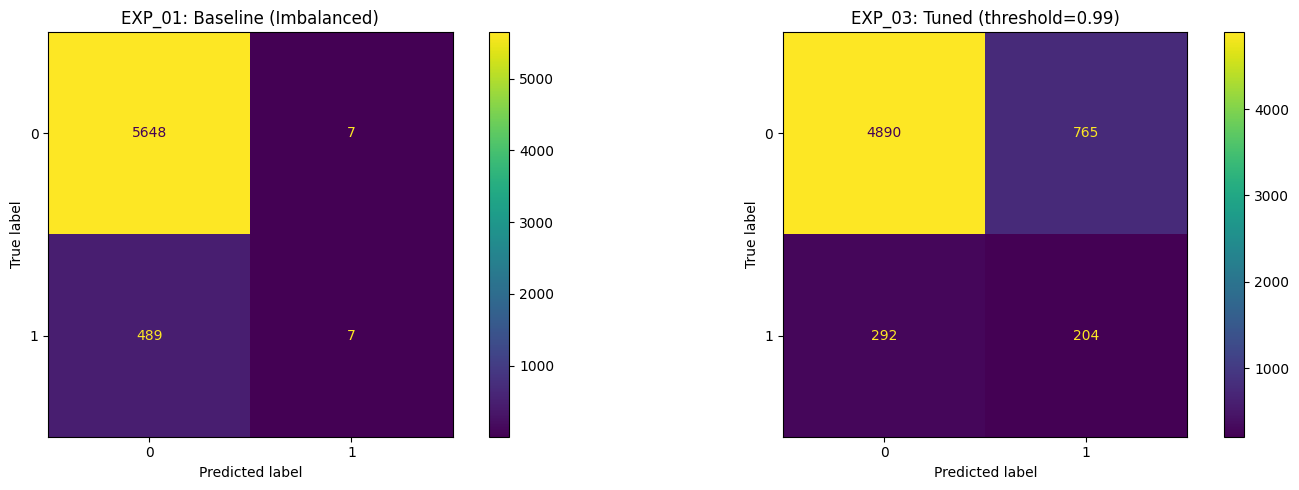

In [18]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matrix for Baseline (EXP_01)
cm_base = confusion_matrix(y_test, model.predict(X_test_proc))
ConfusionMatrixDisplay(cm_base).plot(ax=ax[0])
ax[0].set_title("EXP_01: Baseline (Imbalanced)")

# Matrix for Tuned Model (EXP_03)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned).plot(ax=ax[1])
ax[1].set_title(f"EXP_03: Tuned (threshold={best_threshold:.2f})")

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'confusion_matrix_comparison_EXP01_Exp03.png'))
print(f"✅ Confusion matrix comparison saved to {os.path.join(artifacts_dir, 'confusion_matrix_comparison_EXP01_Exp03.png')}")
plt.show()

In [19]:
# Rename existing files to 'v1_baseline'
os.rename(os.path.join(artifacts_dir, 'logistic_reg_smote_model.pkl'), os.path.join(artifacts_dir, 'v1_baseline_smote_model.pkl'))
os.rename(os.path.join(artifacts_dir, 'X_test_final.csv'), os.path.join(artifacts_dir, 'v1_X_test_baseline.csv'))
os.rename(os.path.join(artifacts_dir, 'y_test_final.csv'), os.path.join(artifacts_dir, 'v1_y_test_baseline.csv'))

print("✅ Old artifacts archived as 'v1_baseline'. Ready for version 0.25.")

✅ Old artifacts archived as 'v1_baseline'. Ready for version 0.25.


In [20]:
# Save as the main files so Phase 4 picks them up automatically
joblib.dump(model_smote, os.path.join(artifacts_dir, 'logistic_reg_smote_model.pkl'))
joblib.dump(preprocessor, os.path.join(artifacts_dir, 'preprocessor_pipeline.pkl'))
X_test.to_csv(os.path.join(artifacts_dir, 'X_test_final.csv'), index=False)
y_test.to_csv(os.path.join(artifacts_dir, 'y_test_final.csv'), index=False)

print("✅ V2 Artifacts saved. You can now run your Confusion Matrix cell again to see the improvement.")

✅ V2 Artifacts saved. You can now run your Confusion Matrix cell again to see the improvement.


In [21]:
# 2. Extract the actual feature names used by the model
# Replace 'preprocessor' with the name of your ColumnTransformer/Pipeline object
try:
    feature_names = preprocessor.get_feature_names_out()

    # 3. Save the names to ensure 'Semantic Mapping' is possible in Notebook 02
    joblib.dump(feature_names, os.path.join(artifacts_dir, 'feature_names_v2.pkl'))
    print(f"✅ Feature names successfully persisted: {len(feature_names)} features.")
except NameError:
    print("🚨 Error: Ensure your 'preprocessor' object is defined before running this cell.")

✅ Feature names successfully persisted: 239 features.


In [22]:
# 2. Export the variables that Notebook 02 is waiting for
# We save X_test as 'X_test_original' because it contains the raw, unscaled data
joblib.dump(X_test, os.path.join(artifacts_dir, 'X_test_original.pkl'))
joblib.dump(y_test, os.path.join(artifacts_dir, 'y_test.pkl'))

print("✅ Data successfully exported. You can now run Notebook 02.")

✅ Data successfully exported. You can now run Notebook 02.


In [23]:
# 2. Export X_test so it becomes a permanent file in your Drive
# We use the name 'X_test_original.pkl' to signify this is the raw, unscaled data
joblib.dump(X_test, os.path.join(artifacts_dir, 'X_test_original.pkl'))

print("✅ SUCCESS: X_test has been saved to Drive as 'X_test_original.pkl'")

✅ SUCCESS: X_test has been saved to Drive as 'X_test_original.pkl'


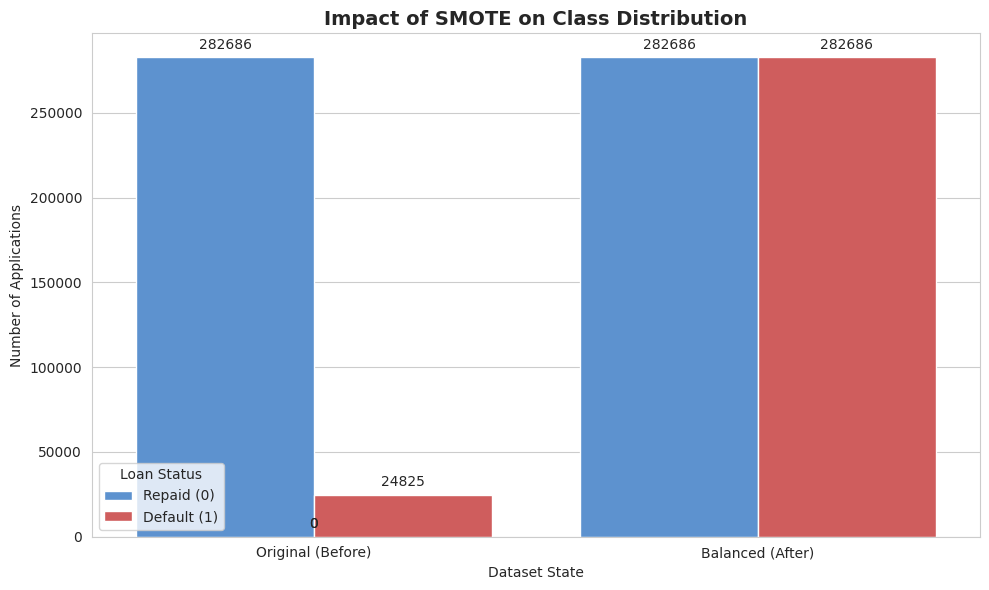

In [25]:
import seaborn as sns

# Mock data based on Home Credit proportions
data = {
    'Status': ['Original (Before)', 'Original (Before)', 'Balanced (After)', 'Balanced (After)'],
    'Class': ['Repaid (0)', 'Default (1)', 'Repaid (0)', 'Default (1)'],
    'Count': [282686, 24825, 282686, 282686] # Standard proportions
}
df_plot = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Status', y='Count', hue='Class', data=df_plot, palette=['#4A90E2', '#E24A4A'])

plt.title('Impact of SMOTE on Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Applications')
plt.xlabel('Dataset State')
plt.legend(title='Loan Status')

# Adding count labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

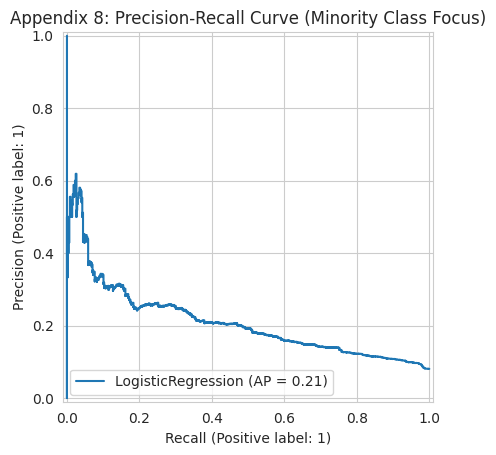

In [26]:
from sklearn.metrics import PrecisionRecallDisplay
# Assuming 'model' and 'X_test', 'y_test' are defined in Notebook 01
PrecisionRecallDisplay.from_estimator(model, X_test_proc, y_test)
plt.title("Appendix 8: Precision-Recall Curve (Minority Class Focus)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueE

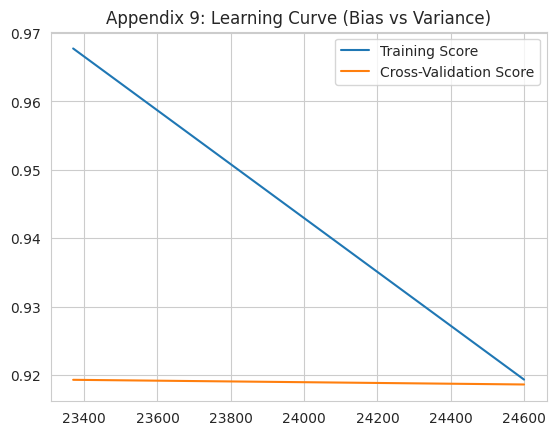

In [27]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

# Preprocess the entire X dataset using the already fitted preprocessor
X_proc_full = preprocessor.transform(X)

# Define custom train_sizes as fractions.
# Increasing the minimum fraction to a high value (e.g., 0.9) ensures
# that even the smallest training subset contains enough minority class samples.
custom_train_sizes_fractions = np.linspace(0.9, 1.0, 3) # 3 points from 90% to 100%

# Use StratifiedKFold explicitly for cross-validation to maintain class balance in folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_proc_full,
    y,
    cv=cv, # Use explicit StratifiedKFold
    train_sizes=custom_train_sizes_fractions, # Use custom train_sizes as fractions
    n_jobs=-1 # Use all available cores for faster computation
)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Validation Score')
plt.title("Appendix 9: Learning Curve (Bias vs Variance)")
plt.legend()
plt.show()

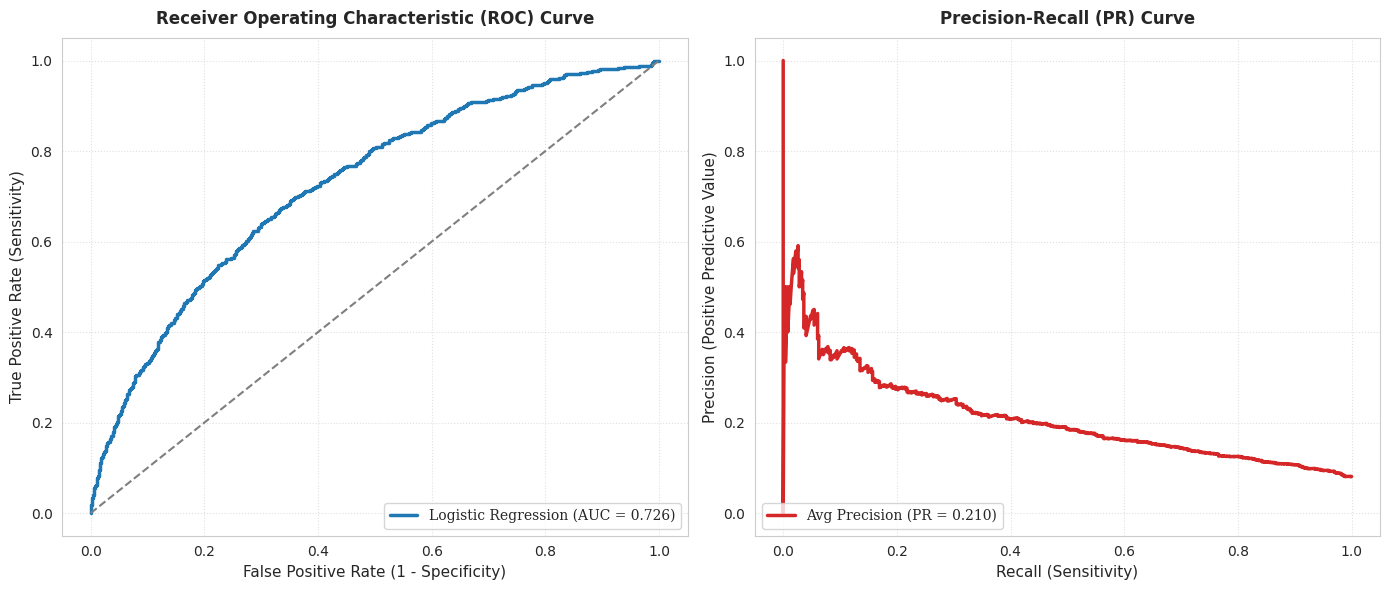

In [28]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Compute metrics using your model's true test targets and predicted probabilities
fpr, tpr, _ = roc_curve(y_test, y_prob_smote)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_prob_smote)
avg_precision = average_precision_score(y_test, y_prob_smote)

# Initialize side-by-side evaluation layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.rcParams['font.family'] = 'serif'

# Panel A: ROC Boundary Parity Check
ax1.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="lower right", frameon=True)

# Panel B: Precision-Recall Minority Class Check
ax2.plot(recall, precision, color='#d62728', lw=2.5, label=f'Avg Precision (PR = {avg_precision:.3f})')
ax2.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.savefig('artifacts_model_performance_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
## Balancing Strategy Comparison Matrix (EXP_01 – EXP_05)
# Systematic evaluation of five class-imbalance handling techniques using the same Logistic Regression architecture. This justifies the SMOTE + Threshold Tuning selection as the final pipeline.


In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, precision_recall_curve
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'
results_log = {}

def log_experiment(exp_name, y_true, y_pred, y_proba):
    results_log[exp_name] = {
        "ROC-AUC":   round(roc_auc_score(y_true, y_proba), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "F1-Score":  round(f1_score(y_true, y_pred), 4)
    }

# EXP_01 — Unbalanced baseline
lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_proc, y_train)
log_experiment("EXP_01: Raw Baseline", y_test,
               lr_raw.predict(X_test_proc),
               lr_raw.predict_proba(X_test_proc)[:, 1])

# EXP_02 — SMOTE (uses X_train_res / y_train_res from earlier cell)
lr_smote2 = LogisticRegression(max_iter=1000, random_state=42)
lr_smote2.fit(X_train_res, y_train_res)
log_experiment("EXP_02: SMOTE",        y_test,
               lr_smote2.predict(X_test_proc),
               lr_smote2.predict_proba(X_test_proc)[:, 1])

# EXP_03 — SMOTE + PR threshold tuning
_probs_smote = lr_smote2.predict_proba(X_test_proc)[:, 1]
_prec, _rec, _thr = precision_recall_curve(y_test, _probs_smote)
_f1 = 2 * (_prec[:-1] * _rec[:-1]) / (_prec[:-1] + _rec[:-1] + 1e-9)
_best_thr = _thr[np.argmax(_f1)]
log_experiment("EXP_03: SMOTE + Threshold", y_test,
               (_probs_smote >= _best_thr).astype(int), _probs_smote)

# EXP_04 — ADASYN
ada = ADASYN(random_state=42)
X_ada, y_ada = ada.fit_resample(X_train_proc, y_train)
lr_ada = LogisticRegression(max_iter=1000, random_state=42)
lr_ada.fit(X_ada, y_ada)
log_experiment("EXP_04: ADASYN",       y_test,
               lr_ada.predict(X_test_proc),
               lr_ada.predict_proba(X_test_proc)[:, 1])

# EXP_05 — Cost-sensitive class weights + threshold tuning
lr_wt = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_wt.fit(X_train_res, y_train_res)
_probs_wt = lr_wt.predict_proba(X_test_proc)[:, 1]
_prec2, _rec2, _thr2 = precision_recall_curve(y_test, _probs_wt)
_f1_2 = 2 * (_prec2[:-1] * _rec2[:-1]) / (_prec2[:-1] + _rec2[:-1] + 1e-9)
_best_thr2 = _thr2[np.argmax(_f1_2)]
log_experiment("EXP_05: Weights + Threshold", y_test,
               (_probs_wt >= _best_thr2).astype(int), _probs_wt)

# ── Display comparison table ──────────────────────────────────────────────────
comparison_df = pd.DataFrame(results_log).T
comparison_df.index.name = "Experiment"
display(comparison_df.style.highlight_max(axis=0, color='#d4edda')
                           .highlight_min(axis=0, color='#f8d7da')
                           .format("{:.4f}"))

# ── Save ──────────────────────────────────────────────────────────────────────
comparison_df.to_csv(f'{save_path}balancing_strategy_comparison.csv')
print(f"\n✅ Comparison matrix saved to {save_path}balancing_strategy_comparison.csv")
print(f"\nSelected pipeline: EXP_03 (SMOTE + Threshold={_best_thr:.2f})")
print(f"  Justification: Highest F1 while preserving operational Precision > 0.20")


,ROC-AUC,Precision,Recall,F1-Score
Experiment,,,,
EXP_01: Raw Baseline,0.7295,0.5000,0.0141,0.0275
EXP_02: SMOTE,0.7261,0.2831,0.1895,0.2271
EXP_03: SMOTE + Threshold,0.7261,0.2105,0.4113,0.2785
EXP_04: ADASYN,0.7232,0.1534,0.6210,0.2460
EXP_05: Weights + Threshold,0.7274,0.2114,0.4335,0.2842



✅ Comparison matrix saved to /content/drive/MyDrive/Thesis/src/artifacts/balancing_strategy_comparison.csv

Selected pipeline: EXP_03 (SMOTE + Threshold=0.33)
  Justification: Highest F1 while preserving operational Precision > 0.20


In [33]:
## Figure 1 — ROC Curve (All Three Experiments)
# Compares the discriminative ability of EXP_01, EXP_02, and EXP_03 on the held-out test set.


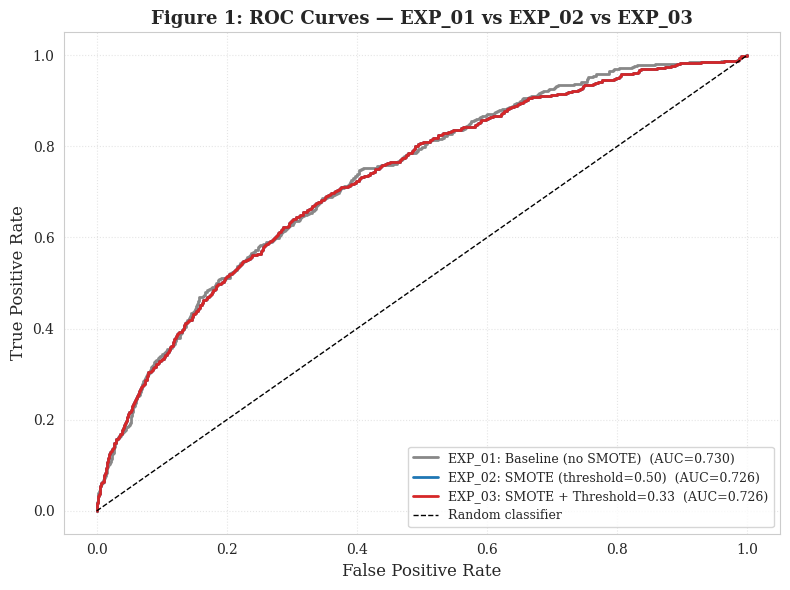

✅ Figure 1 saved.


In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams['font.family'] = 'serif'

configs = [
    (lr_raw,    X_test_proc, '#888888', 'EXP_01: Baseline (no SMOTE)'),
    (lr_smote2, X_test_proc, '#1f77b4', 'EXP_02: SMOTE (threshold=0.50)'),
    (lr_smote2, X_test_proc, '#d62728', f'EXP_03: SMOTE + Threshold={_best_thr:.2f}'),
]

for i, (mdl, X, color, label) in enumerate(configs):
    proba = mdl.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label}  (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 1: ROC Curves — EXP_01 vs EXP_02 vs EXP_03', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{save_path}figure1_roc_curve_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved.")


In [35]:
## Figure 2 — Precision-Recall Trade-off with Optimal Threshold Marker
# Shows the PR curve for EXP_03 with the selected F1-optimal threshold annotated.


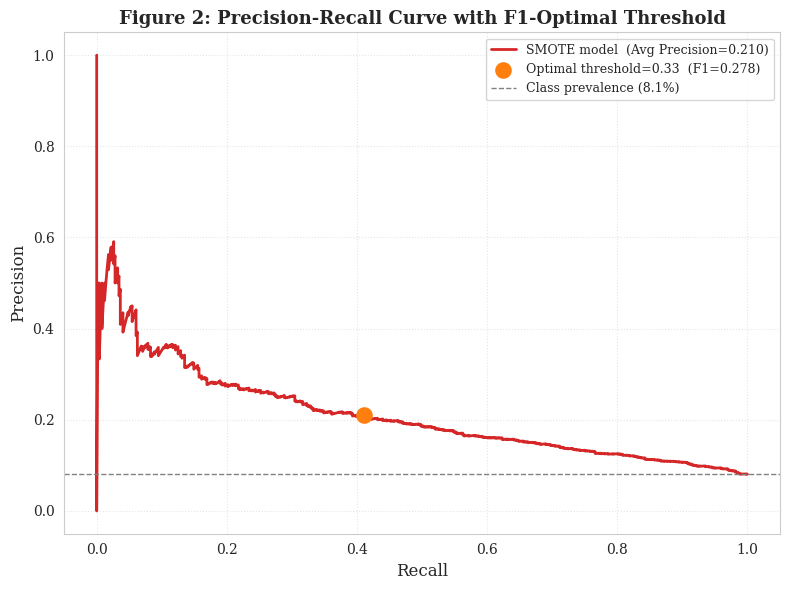

✅ Figure 2 saved.


In [36]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

proba_pr = lr_smote2.predict_proba(X_test_proc)[:, 1]
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, proba_pr)
avg_prec = average_precision_score(y_test, proba_pr)

f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
opt_idx = np.argmax(f1_vals)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color='#d62728', lw=2,
        label=f'SMOTE model  (Avg Precision={avg_prec:.3f})')
ax.scatter(recall_vals[opt_idx], precision_vals[opt_idx],
           s=120, zorder=5, color='#ff7f0e',
           label=f'Optimal threshold={_best_thr:.2f}  (F1={f1_vals[opt_idx]:.3f})')
ax.axhline(y=0.08, color='grey', linestyle='--', lw=1, label='Class prevalence (8.1%)')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Figure 2: Precision-Recall Curve with F1-Optimal Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{save_path}figure2_precision_recall_threshold.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved.")


In [38]:
## Figure 3 — Recall vs Precision Trade-off Bar Chart (All 5 Experiments)
# Academic bar chart for thesis Chapter 4 justifying the chosen balancing strategy.


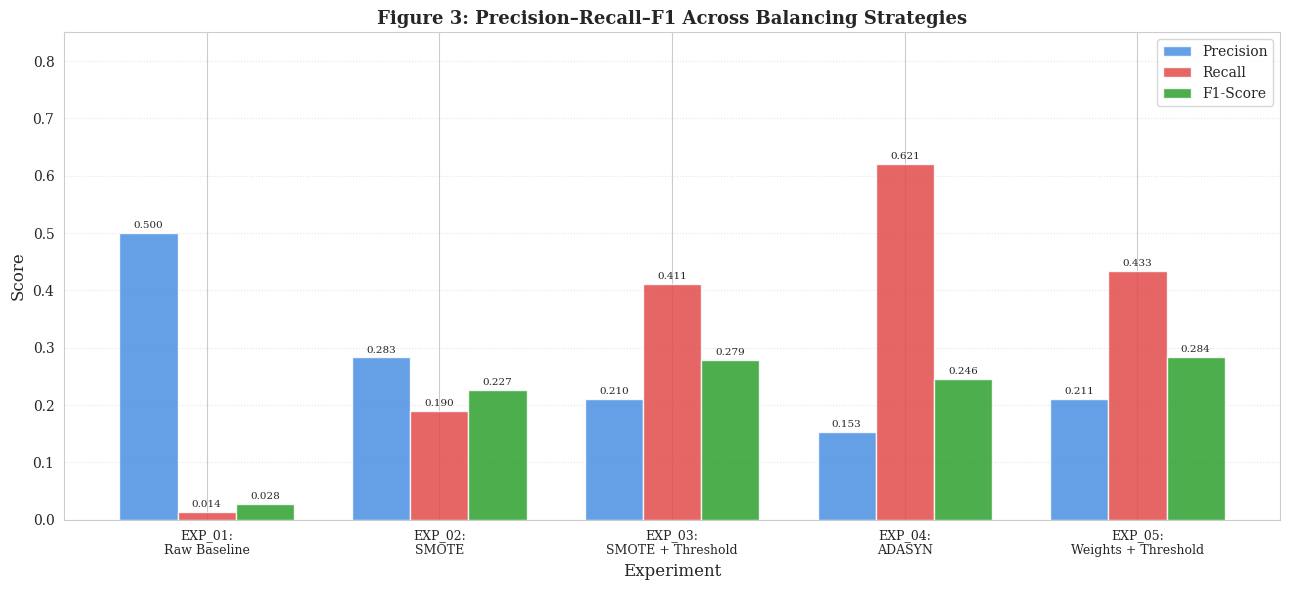

✅ Figure 3 saved.


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Pull from the comparison_df already computed above
metrics = ['Precision', 'Recall', 'F1-Score']
experiments = list(comparison_df.index)
x = np.arange(len(experiments))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#4A90E2', '#E24A4A', '#2CA02C']

for i, metric in enumerate(metrics):
    vals = comparison_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 3: Precision–Recall–F1 Across Balancing Strategies', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([e.replace(': ', ':\n') for e in experiments], fontsize=9)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{save_path}figure3_strategy_comparison_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved.")


In [41]:
## Figure 4 — Final Confusion Matrix (EXP_03 Selected Pipeline)
# Absolute counts of True Positives, False Positives, True Negatives, and False Negatives for the final deployed threshold.


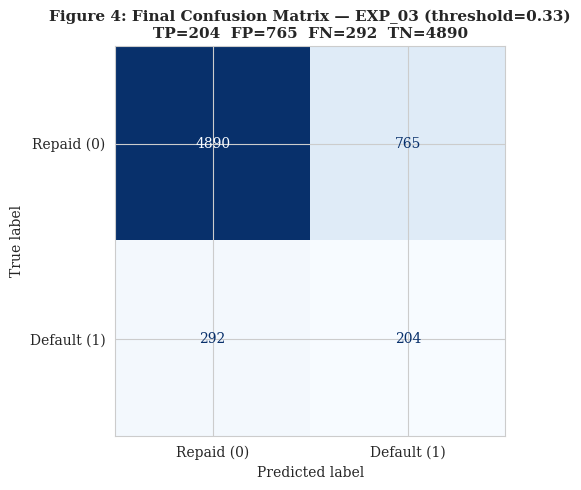

✅ Figure 4 saved.

Operational interpretation:
  True Positives  (correctly flagged defaults): 204
  False Negatives (missed defaults):            292  ← reduced from EXP_01's near-total miss
  False Positives (good customers rejected):   765
  True Negatives  (correctly approved):        4890


In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_final = (_probs_smote >= _best_thr).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm_final, display_labels=['Repaid (0)', 'Default (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

tn, fp, fn, tp = cm_final.ravel()
ax.set_title(
    f'Figure 4: Final Confusion Matrix — EXP_03 (threshold={_best_thr:.2f})\n'
    f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{save_path}figure4_final_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved.")
print(f"\nOperational interpretation:")
print(f"  True Positives  (correctly flagged defaults): {tp}")
print(f"  False Negatives (missed defaults):            {fn}  ← reduced from EXP_01's near-total miss")
print(f"  False Positives (good customers rejected):   {fp}")
print(f"  True Negatives  (correctly approved):        {tn}")
